# Tide-Table 🌊
### The one valuation signal that actually forecasts returns — over a decade

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts long-run returns?: Confirmed](https://img.shields.io/badge/Forecasts_long--run_returns%3F-Confirmed-8b949e?style=flat-square)

After a string of valuation 'signals' that didn't work, here's one that does: the Shiller CAPE. When stocks are cheap relative to a decade of earnings, the next decade's returns are high; when expensive, low. It explains ~28% of 10-year returns — *real* and useful. The catch is the horizon: it tells you the tide, not tomorrow's wave.

> 📓 **Plain-language layer.** The R², the buckets and the timing caveat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (tide_table/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from tide_table import data, strategy as st
d = data.fetch_shiller(start_year=1900)        # cache-first
ten = st.forward_corr(d["cape"], d["fwd10"]); one = st.forward_corr(d["cape"], d["fwd1"])


## The answer first 🎯

| The question | The data (1900–2016) |
|---|---|
| "Does CAPE forecast returns?" | Yes — **R² 0.28** at 10 years, corr **−0.51**. |
| "Cheap vs expensive?" | Cheap decades **+10.2%/yr** real vs expensive **+4.0%**. |
| "Can I time with it?" | No — at **1 year** R² is just **0.05**. |

## 1 · The claim

Campbell & Shiller (1998): the cyclically-adjusted P/E (price ÷ 10-year average real earnings) mean-reverts, so a high CAPE precedes low long-run returns and a low CAPE precedes high ones.

## 2 · So what?

If valuation forecasts the next decade, it's the single most useful number for setting return expectations and asset allocation. But 'forecasts the decade' and 'times the market' are different claims — and conflating them is how investors get hurt.

## 3 · How would we even know?

Line up CAPE against the **realised next-10-year real return**, measure the correlation and R², sort history into cheap/expensive buckets — then run the *same* test at a 1-year horizon to expose the timing limit.

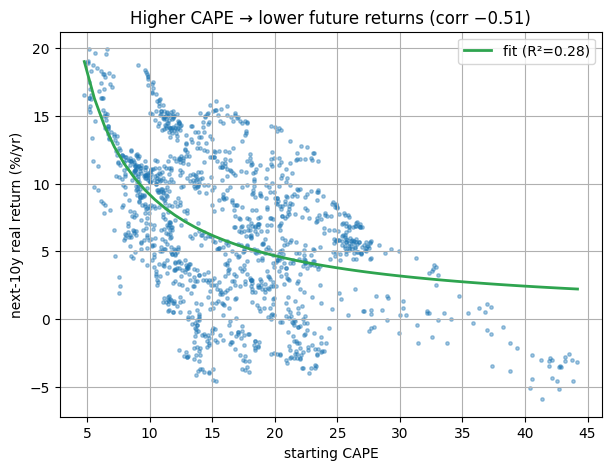

In [2]:
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(d['cape'], d['fwd10']*100, s=6, alpha=.4)
xs=np.linspace(d['cape'].dropna().min(), d['cape'].dropna().max(), 50)
b0,b1=st.implied_return(d['cape'],d['fwd10'])
ax.plot(xs,(b0+b1/xs)*100,color='#2ea44f',lw=2,label=f"fit (R²={ten['r2']:.2f})")
ax.set_xlabel('starting CAPE'); ax.set_ylabel('next-10y real return (%/yr)')
ax.set_title('Higher CAPE → lower future returns (corr −0.51)'); ax.legend(); plt.show()

## 4 · The teardown

The scatter slopes clearly down — and the bucket ladder is monotone. Then watch the same signal fail at one year.

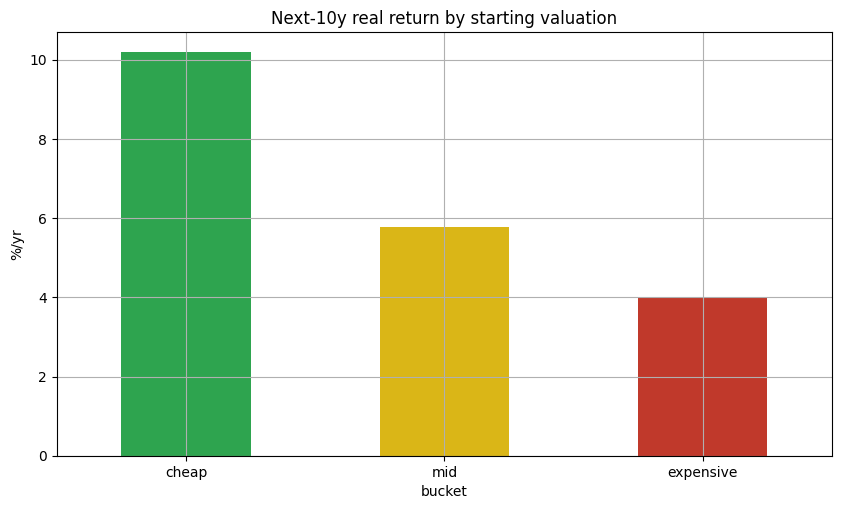

R²: 10-year 0.28  vs  1-year 0.05  -> a forecaster, not a timer


In [3]:
b=st.bucket_returns(d['cape'],d['fwd10'])
ax=(b*100).plot.bar(rot=0,color=['#2ea44f','#dab617','#c0392b'],title='Next-10y real return by starting valuation')
ax.set_ylabel('%/yr'); plt.show()
print(f"R²: 10-year {ten['r2']:.2f}  vs  1-year {one['r2']:.2f}  -> a forecaster, not a timer")

**Read it plainly.** Buy cheap, earn ~10%/yr real over the decade; buy expensive, ~4%. But the 1-year R² of 0.05 means CAPE says almost nothing about next year — an expensive market can keep climbing for years.

## 5 · The verdict

**Signal: Real** — R² 0.28, monotone ladder. **Tradability: Fragile** — useless as a timer (1y R² 0.05). **Forecasts long-run returns?: Confirmed** — the valuation signal the Fed Model wasn't.

## 6 · Could you actually trade it?

Not as a timer — markets stay expensive for years. Its real use is **expectations and allocation**: at today's CAPE (~31) the fit implies about **+3%/yr real** for the next decade — plan accordingly, don't try to jump in and out.

## 7 · Going further 🚪

The quants notebook has the implied-return fit and the horizon contrast. Contrast with [Study 47 Paper-Moon](../../47-paper-moon/): valuation (CAPE/EP) works, the Fed Model's bond comparison doesn't.